<div style="background: linear-gradient(135deg, #1a1a2e 0%, #16213e 50%, #0f3460 100%); padding: 40px 30px; border-radius: 12px; margin-bottom: 10px;">
    <h1 style="color:#e2b96f; font-family:'Segoe UI', sans-serif; font-size:2.2em; margin:0 0 8px 0;">
        Introdução ao Aprendizado de Máquina
    </h1>
    <h2 style="color:#a8d8ea; font-family:'Segoe UI', sans-serif; font-size:1.3em; margin:0 0 6px 0; font-weight:400;">
        Aula 02 — Ciência de Dados e Visualização
    </h2>
    <h3 style="color:#e2b96f; font-family:'Segoe UI', sans-serif; font-size:1.05em; margin:0 0 12px 0; font-weight:500;">
        Prática — Do Dado ao Gráfico com o Dataset Titanic
    </h3>
    <p style="color:#ccc; font-family:'Segoe UI', sans-serif; font-size:0.9em; margin:0;">
        Prof. Felipe Amaral
    </p>
</div>

<div style="display:flex; gap:10px; margin-top:10px; flex-wrap:wrap;">
    <span style="background:#0f3460; color:#a8d8ea; padding:5px 14px; border-radius:20px; font-size:0.85em;">FIAP</span>
    <span style="background:#0f3460; color:#a8d8ea; padding:5px 14px; border-radius:20px; font-size:0.85em;">Python 3</span>
    <span style="background:#0f3460; color:#a8d8ea; padding:5px 14px; border-radius:20px; font-size:0.85em;">Dataset Titanic</span>
</div>


## Por que o Titanic?

Em 15 de abril de 1912, o RMS Titanic afundou no Atlântico Norte após colidir com um iceberg.
Das **2.224 pessoas a bordo, apenas 710 sobreviveram** — uma taxa de sobrevivência de 32%.

Os dados dos passageiros foram registrados e hoje formam um dos datasets mais usados no mundo para aprender análise de dados.

> *"A partir dos dados disponíveis, o que podemos aprender sobre quem sobreviveu?"*

Essa é exatamente a pergunta que um **cientista de dados** faria. Nesta aula você vai fazer o mesmo percurso: carregar dados brutos, limpá-los, calcular estatísticas e criar gráficos que revelam padrões reais.

---

## O que você vai fazer hoje

| Parte | Tema | O que vai aprender |
|-------|------|-------------------|
| **1** | Primeiro contato com os dados | Carregar e inspecionar um dataset com pandas |
| **2** | Limpeza básica | Identificar e tratar valores faltantes |
| **3** | Estatísticas descritivas | Calcular médias, taxas e distribuições com groupby |
| **4** | Visualizações progressivas | Criar 5 tipos de gráfico com matplotlib e seaborn |
| **5** | Desafio autônomo | Responder perguntas analíticas reais sem código pronto |

> **Tempo estimado: 30 minutos**

> **Sem experiência prévia?** Sem problema. Cada célula tem comentários explicando o que está acontecendo. Execute com Shift+Enter e leia os resultados.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

# Configuração visual padrão da aula
plt.rcParams.update({
    "figure.figsize":     (10, 5),
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "axes.titlesize":     13,
    "axes.labelsize":     11,
    "xtick.labelsize":    10,
    "ytick.labelsize":    10,
})
sns.set_theme(style="whitegrid", palette="muted")

print("Ambiente configurado com sucesso!")
print(f"   pandas  {pd.__version__}")
print(f"   numpy   {np.__version__}")
print(f"   seaborn {sns.__version__}")


✅ Ambiente configurado com sucesso!
   pandas  2.2.2
   numpy   2.0.2
   seaborn 0.13.2


---

<div style="background: linear-gradient(90deg, #0f3460 0%, #16213e 100%); padding:20px 25px; border-radius:10px; margin:20px 0;">
    <div>
        <span style="color:#e2b96f; font-size:0.85em; font-weight:bold; letter-spacing:2px;">PARTE 1</span>
        <h2 style="color:white; margin:4px 0 0 0; font-family:'Segoe UI',sans-serif;">Primeiro Contato com os Dados</h2>
        <p style="color:#a8d8ea; margin:6px 0 0 0; font-size:0.9em;">"Você acabou de receber um dataset. O que faz primeiro?"</p>
    </div>
</div>

### O que é um DataFrame?

Quando carregamos dados no pandas, eles ficam em um objeto chamado **DataFrame** — pense como uma planilha do Excel viva dentro do Python: linhas são registros (cada passageiro), colunas são atributos (idade, classe, sobrevivência...).

O Seaborn já tem o dataset Titanic embutido. Não precisa baixar nada.

### Dicionário das colunas — leia antes de rodar o código

| Coluna | Tipo | Significado |
|--------|------|-------------|
| `survived` | Numérico (0/1) | **Alvo** — 1 = sobreviveu, 0 = não sobreviveu |
| `pclass` | Numérico (1/2/3) | Classe do bilhete (1ª = mais cara, 3ª = mais barata) |
| `sex` | Categórico | Gênero do passageiro |
| `age` | Numérico | Idade em anos |
| `fare` | Numérico | Tarifa paga pelo bilhete (em libras esterlinas) |
| `embarked` | Categórico | Porto de embarque: C=Cherbourg, Q=Queenstown, S=Southampton |
| `deck` | Categórico | Convés do camarote (A a G) — atenção: muitos valores faltantes! |

<div style="background:#e3f2fd; border-left:5px solid #1565c0; padding:12px 18px; border-radius:6px; margin:12px 0;">
<strong style="color:#1565c0;">O que esperar da célula abaixo:</strong><br>
<span style="color:#1565c0;">Vamos carregar o dataset e usar 3 métodos básicos do pandas para conhecê-lo:<br>
<code>.shape</code> → quantas linhas e colunas<br>
<code>.head()</code> → ver as primeiras linhas<br>
<code>.info()</code> → ver os tipos de dados e quantos valores faltantes há</span>
</div>


In [ ]:
# Carregando o dataset
df = sns.load_dataset("titanic")

print(f"Shape do dataset: {df.shape}")
print(f"  → {df.shape[0]} passageiros (linhas)")
print(f"  → {df.shape[1]} colunas (atributos por passageiro)")


In [ ]:
# .head() mostra as primeiras 5 linhas
# É o jeito mais rápido de ver como os dados estão estruturados
df.head()


In [ ]:
# .info() mostra: tipo de dado de cada coluna + quantos valores NÃO são nulos
# Colunas com "non-null count" menor que o total têm valores faltantes — anote!
df.info()


---

<div style="background: linear-gradient(90deg, #0f3460 0%, #16213e 100%); padding:20px 25px; border-radius:10px; margin:20px 0;">
    <div>
        <span style="color:#e2b96f; font-size:0.85em; font-weight:bold; letter-spacing:2px;">PARTE 2</span>
        <h2 style="color:white; margin:4px 0 0 0; font-family:'Segoe UI',sans-serif;">Limpeza Básica</h2>
        <p style="color:#a8d8ea; margin:6px 0 0 0; font-size:0.9em;">"Antes de analisar, precisamos confiar nos dados."</p>
    </div>
</div>

### Por que limpar dados?

Em qualquer projeto real, dados chegam "sujos": valores faltantes, duplicatas, tipos errados. Se você analisar dados sujos sem tratamento, suas conclusões podem ser completamente erradas.

**Valores faltantes** (chamados de `NaN` no pandas) são os mais comuns. Existem 3 estratégias:

| Situação | Decisão |
|----------|---------|
| Coluna com **> 50% NaN** | Remover a coluna — não tem informação suficiente |
| Coluna **numérica** com NaN | Preencher com a **mediana** (mais robusta que a média quando há outliers) |
| Coluna **categórica** com NaN | Preencher com a **moda** (valor mais frequente) |

> **Por que mediana e não média?** Se 10 passageiros têm 20-30 anos e 1 tem 200 anos (erro de digitação), a média fica distorcida. A mediana não.


In [ ]:
# Contando NaN por coluna — a primeira pergunta após carregar qualquer dataset
nan_contagem = df.isnull().sum()
nan_pct      = (df.isnull().sum() / len(df) * 100).round(1)

resumo_nan = pd.DataFrame({
    "NaN (qtd)": nan_contagem,
    "NaN (%)":   nan_pct
}).sort_values("NaN (%)", ascending=False)

print("Valores faltantes por coluna:")
print(resumo_nan[resumo_nan["NaN (qtd)"] > 0].to_string())
print()
print("Decisões:")
print("  deck     → remover (77% de NaN — quase nada útil)")
print("  age      → preencher com mediana (~20% de NaN)")
print("  embarked → preencher com moda (apenas 2 NaN)")


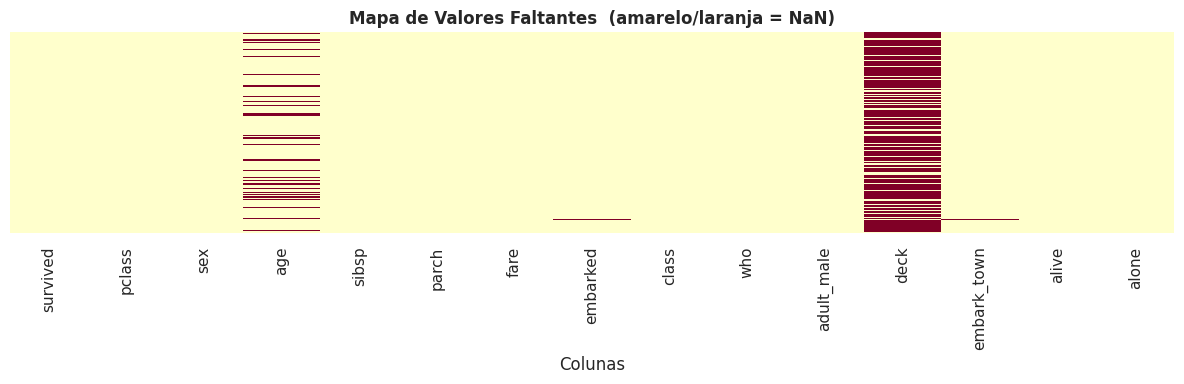

Observação: 'deck' tem ~77% de NaN — provavelmente não conseguiremos usá-la.
'age' tem ~20% de NaN — podemos preencher com a mediana.
'embarked' tem apenas 2 NaN — podemos preencher com a moda.


In [ ]:
# Heatmap de valores faltantes
fig, ax = plt.subplots(figsize=(12, 4))

sns.heatmap(
    df.isnull(),
    yticklabels=False,
    cbar=False,
    cmap="YlOrRd",
    ax=ax
)
ax.set_title("Mapa de Valores Faltantes  (amarelo/laranja = NaN)", fontweight="bold")
ax.set_xlabel("Colunas")
plt.tight_layout()
plt.show()

print("Observação: 'deck' tem ~77% de NaN — provavelmente não conseguiremos usá-la.")
print("'age' tem ~20% de NaN — podemos preencher com a mediana.")
print("'embarked' tem apenas 2 NaN — podemos preencher com a moda.")


### Agora é com você — Missão 2

<div style="background:#fde8d8; border-left:5px solid #a04000; padding:14px 20px; border-radius:6px; margin:12px 0;">
<strong style="color:#a04000;">MISSÃO 2 — Complete o código na célula abaixo:</strong><br><br>
<span style="color:#a04000;">
• <code>age</code>: preencha os NaN com a <strong>mediana</strong> da coluna (<code>.fillna()</code> + <code>.median()</code>)<br>
• <code>embarked</code>: preencha os 2 NaN com a <strong>moda</strong> (<code>.fillna()</code> + <code>.mode()[0]</code>)<br>
• <code>deck</code>: <strong>remova</strong> a coluna (<code>.drop(columns=[...])</code>)<br>
• Verifique no final que não há mais NaN nas colunas tratadas
</span>
</div>


In [ ]:
df_limpo = df.copy()   # sempre trabalhe em uma cópia — preserve o original!

# 1. Preencher 'age' com a mediana
# df_limpo["age"] = df_limpo["age"].fillna( ??? )

# 2. Preencher 'embarked' com a moda
# df_limpo["embarked"] = df_limpo["embarked"].fillna( ??? )

# 3. Remover a coluna 'deck'
# df_limpo = df_limpo.drop(columns=["deck"])

# Verificação
print("NaN restantes nas colunas tratadas:")
for col in ["age", "embarked", "deck"]:
    if col in df_limpo.columns:
        print(f"  {col}: {df_limpo[col].isnull().sum()} NaN")
    else:
        print(f"  {col}: coluna removida ✓")


In [ ]:
# GABARITO DA MISSÃO 2 (descomente para ver)
# df_limpo = df.copy()
# df_limpo["age"]      = df_limpo["age"].fillna(df_limpo["age"].median())
# df_limpo["embarked"] = df_limpo["embarked"].fillna(df_limpo["embarked"].mode()[0])
# df_limpo = df_limpo.drop(columns=["deck"])
# print(f"Shape antes: {df.shape} | depois: {df_limpo.shape}")


In [ ]:
# Célula de segurança — execute sempre após a Missão 2
# Garante que df_limpo está correto mesmo se você não completou o exercício.
# Assim as partes seguintes do notebook sempre funcionam.
df_limpo = df.copy()
df_limpo["age"]      = df_limpo["age"].fillna(df_limpo["age"].median())
df_limpo["embarked"] = df_limpo["embarked"].fillna(df_limpo["embarked"].mode()[0])
df_limpo = df_limpo.drop(columns=["deck"])

n_dup = df_limpo.duplicated().sum()
if n_dup > 0:
    df_limpo = df_limpo.drop_duplicates()

print(f"df_limpo pronto! Shape: {df_limpo.shape} | NaN restantes: {df_limpo.isnull().sum().sum()}")


---

<div style="background: linear-gradient(90deg, #0f3460 0%, #16213e 100%); padding:20px 25px; border-radius:10px; margin:20px 0;">
    <div>
        <span style="color:#e2b96f; font-size:0.85em; font-weight:bold; letter-spacing:2px;">PARTE 3</span>
        <h2 style="color:white; margin:4px 0 0 0; font-family:'Segoe UI',sans-serif;">Estatísticas Descritivas</h2>
        <p style="color:#a8d8ea; margin:6px 0 0 0; font-size:0.9em;">"Números antes de gráficos — sempre."</p>
    </div>
</div>

### Por que começar pelos números?

A regra dos cientistas de dados experientes: **calcule antes de plotar**. Os números revelam o que procurar. Os gráficos confirmam.

O método `.describe()` do pandas entrega em uma linha: média, desvio padrão, mínimo, máximo e quartis de todas as colunas numéricas.

| Métrica | O que significa |
|---------|-----------------|
| `count` | Quantos valores não-nulos existem |
| `mean` | Média aritmética |
| `std` | Desvio padrão — o quanto os valores se espalharam em torno da média |
| `50%` | Mediana — o valor do meio quando você ordena todos os valores |
| `min` / `max` | Extremos |

<div style="background:#e8d5f5; border-left:5px solid #5b2c8d; padding:12px 18px; border-radius:6px; margin:12px 0;">
<strong style="color:#5b2c8d;">Dica de leitura:</strong> <span style="color:#5b2c8d;">Quando a média (<code>mean</code>) é muito diferente da mediana (<code>50%</code>), o dado tem outliers ou é assimétrico. Isso vai aparecer claramente nos gráficos depois.</span>
</div>


In [ ]:
# Resumo estatístico de todas as colunas numéricas
df_limpo.describe().round(2)


── Estatísticas descritivas ────────────────────────────


,survived,pclass,age,sibsp,parch,fare
count,775.00,775.00,775.00,775.00,775.00,775.00
mean,0.41,2.25,29.58,0.53,0.42,34.88
std,0.49,0.85,13.77,0.99,0.84,52.41
min,0.00,1.00,0.42,0.00,0.00,0.00
25%,0.00,1.00,21.00,0.00,0.00,8.05
50%,0.00,3.00,28.00,0.00,0.00,15.90
75%,1.00,3.00,36.00,1.00,1.00,34.20
max,1.00,3.00,80.00,8.00,6.00,512.33


In [ ]:
# Taxa de sobrevivência geral
# survived = 1 para quem sobreviveu, 0 para quem não sobreviveu
# Então a MÉDIA de survived é exatamente a taxa de sobrevivência!
total        = len(df_limpo)
sobreviveram = df_limpo["survived"].sum()
taxa_geral   = df_limpo["survived"].mean() * 100

print(f"Total de passageiros:  {total}")
print(f"Sobreviventes:         {sobreviveram}")
print(f"Taxa de sobrevivência: {taxa_geral:.1f}%")


### Agora a pergunta mais importante — Missão 3

<div style="background:#fde8d8; border-left:5px solid #a04000; padding:14px 20px; border-radius:6px; margin:12px 0;">
<strong style="color:#a04000;">MISSÃO 3 — Calcule a taxa de sobrevivência por gênero e por classe.</strong><br><br>
<span style="color:#a04000;">
Use <code>df_limpo.groupby("sex")["survived"].mean()</code> — o <code>groupby</code> agrupa os dados, o <code>.mean()</code> calcula a média de survived dentro de cada grupo.<br><br>
O que os números já sugerem antes de qualquer gráfico?
</span>
</div>


In [ ]:
# (a) Taxa de sobrevivência por gênero
# Dica: .groupby("sex")["survived"].mean() * 100 já dá em percentual
taxa_sexo = ???

# (b) Taxa de sobrevivência por classe
taxa_classe = ???

print("Taxa de sobrevivência por gênero (%):")
print(taxa_sexo)
print("\nTaxa de sobrevivência por classe (%):")
print(taxa_classe)


In [ ]:
# GABARITO DA MISSÃO 3 (descomente para ver)
# taxa_sexo   = df_limpo.groupby("sex")["survived"].mean().round(3) * 100
# taxa_classe = df_limpo.groupby("pclass")["survived"].mean().round(3) * 100
# print("Por gênero:"); print(taxa_sexo)
# print("\nPor classe:"); print(taxa_classe)
# print("\nObservação:")
# print("  Mulheres: ~74% vs homens: ~19%")
# print("  1ª classe: ~63% vs 3ª classe: ~24%")
# print("  'Mulheres e crianças primeiro' era real — os dados confirmam!")


---

<div style="background: linear-gradient(90deg, #0f3460 0%, #16213e 100%); padding:20px 25px; border-radius:10px; margin:20px 0;">
    <div>
        <span style="color:#e2b96f; font-size:0.85em; font-weight:bold; letter-spacing:2px;">PARTE 4</span>
        <h2 style="color:white; margin:4px 0 0 0; font-family:'Segoe UI',sans-serif;">Visualizações Progressivas</h2>
        <p style="color:#a8d8ea; margin:6px 0 0 0; font-size:0.9em;">"Um gráfico, uma pergunta."</p>
    </div>
</div>

### A regra de ouro das visualizações

> **Cada gráfico deve responder a UMA pergunta específica.**

Se você não sabe qual pergunta o gráfico responde, ele provavelmente não deveria existir. Ao longo desta seção, cada gráfico começa com uma pergunta — é assim que um analista de dados pensa na prática.

Vamos cobrir 5 tipos de gráfico, cada um com um uso diferente:

| Tipo | Quando usar |
|------|-------------|
| **Barras** | Comparar categorias |
| **Histograma** | Ver a distribuição de uma variável numérica |
| **Boxplot** | Comparar distribuições entre grupos e ver outliers |
| **Scatter plot** | Ver relação entre duas variáveis numéricas |
| **Heatmap de correlação** | Ver força de relação entre múltiplas variáveis de uma vez |


---

### Gráfico 1 — Barras

**Pergunta:** *"A classe social influenciou a sobrevivência?"*

Um gráfico de barras é ideal para **comparar categorias**. Vamos comparar a taxa de
sobrevivência entre as três classes de passageiros.


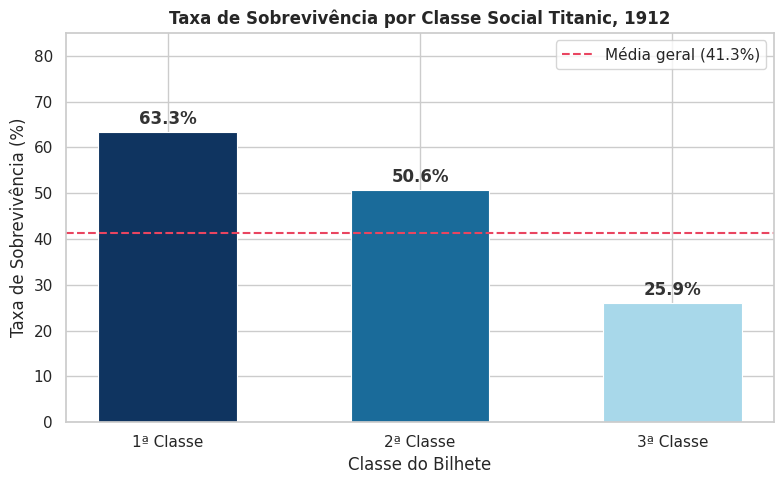

💬 O que você observa? Há uma relação entre classe e sobrevivência?


In [ ]:
# GRÁFICO DE BARRAS
# Ideal para comparar valores entre categorias discretas.
# Boas práticas aplicadas aqui:
#   - eixo Y começa em zero (nunca corte o eixo Y em barras!)
#   - rótulos diretos nas barras (mais rápido de ler que olhar o eixo)
#   - linha de referência com a média geral

Calculando a taxa de sobrevivência por classe
taxa_classe = df_limpo.groupby("pclass")["survived"].mean() * 100

# Criando o gráfico
fig, ax = plt.subplots(figsize=(8, 5))

barras = ax.bar(
    ["1ª Classe", "2ª Classe", "3ª Classe"],
    taxa_classe.values,
    color=["#0f3460", "#1a6b9a", "#a8d8ea"],
    edgecolor="white",
    linewidth=0.8,
    width=0.55,
)

# Adicionando rótulos em cima de cada barra
for barra, valor in zip(barras, taxa_classe.values):
    ax.text(
        barra.get_x() + barra.get_width() / 2,
        barra.get_height() + 1,
        f"{valor:.1f}%",
        ha="center", va="bottom",
        fontsize=12, fontweight="bold", color="#333"
    )

# Boa prática: título claro, rótulos nos eixos, linha de referência
ax.axhline(taxa_geral, color="#e94560", linestyle="--", linewidth=1.5,
           label=f"Média geral ({taxa_geral:.1f}%)")
ax.set_xlabel("Classe do Bilhete")
ax.set_ylabel("Taxa de Sobrevivência (%)")
ax.set_title("Taxa de Sobrevivência por Classe Social Titanic, 1912", fontweight="bold")
ax.set_ylim(0, 85)
ax.legend()

plt.tight_layout()
plt.show()

print("💬 O que você observa? Há uma relação entre classe e sobrevivência?")


<div style="background:#e8d5f5; border-left:5px solid #5b2c8d; padding:14px 20px; border-radius:6px; margin:12px 0;">
<strong style="color:#5b2c8d;">💡 </strong><span style="color:#5b2c8d;">Boa prática aplicada: eixo Y começa em zero, rótulos diretos nas barras (evita o leitor adivinhar o valor), linha tracejada de referência com a média geral.</span>
</div>

---

### Gráfico 2 — Histograma

**Pergunta:** *"Como a idade dos passageiros se distribui?"*

Um histograma mostra a **distribuição de frequências** de uma variável numérica.
Ele divide os valores em intervalos (bins) e conta quantas pessoas caem em cada um.


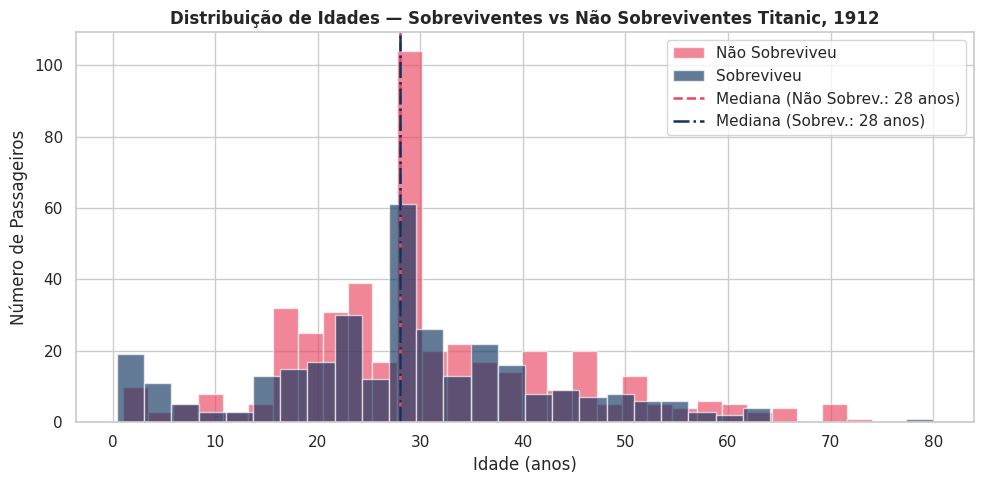

💬 Existe diferença na distribuição de idades entre os grupos?
   Há algum padrão para crianças pequenas (age < 10)?


In [ ]:
# HISTOGRAMA
# Divide os valores em faixas (bins) e conta quantos caem em cada faixa.
# Aqui separamos por cor quem sobreviveu (azul) e quem não sobreviveu (vermelho).
# As linhas tracejadas marcam a mediana de cada grupo — fácil comparar.

fig, ax = plt.subplots(figsize=(10, 5))

# Histograma com separação por sobrevivência
for sobreviveu, label, cor in [(0, "Não Sobreviveu", "#e94560"),
                                (1, "Sobreviveu",     "#0f3460")]:
    subset = df_limpo[df_limpo["survived"] == sobreviveu]["age"]
    ax.hist(subset, bins=30, alpha=0.65, color=cor, label=label, edgecolor="white")

# Linhas de mediana para cada grupo
for sobreviveu, cor, ls in [(0, "#e94560", "--"), (1, "#0f3460", "-.")]:
    mediana = df_limpo[df_limpo["survived"] == sobreviveu]["age"].median()
    ax.axvline(mediana, color=cor, linestyle=ls, linewidth=1.8,
               label=f"Mediana ({'Não Sobrev.' if sobreviveu == 0 else 'Sobrev.'}: {mediana:.0f} anos)")

ax.set_xlabel("Idade (anos)")
ax.set_ylabel("Número de Passageiros")
ax.set_title("Distribuição de Idades — Sobreviventes vs Não Sobreviventes Titanic, 1912", fontweight="bold")
ax.legend()

plt.tight_layout()
plt.show()

print("💬 Existe diferença na distribuição de idades entre os grupos?")
print("   Há algum padrão para crianças pequenas (age < 10)?")


---

### Gráfico 3 — Boxplot

**Pergunta:** *"Há diferença de idade entre sobreviventes e não sobreviventes, por gênero?"*

O boxplot é excelente para **comparar distribuições entre grupos** e identificar outliers.
Cada caixa mostra: mediana (linha central), 1º e 3º quartis (bordas), e whiskers (valores extremos).


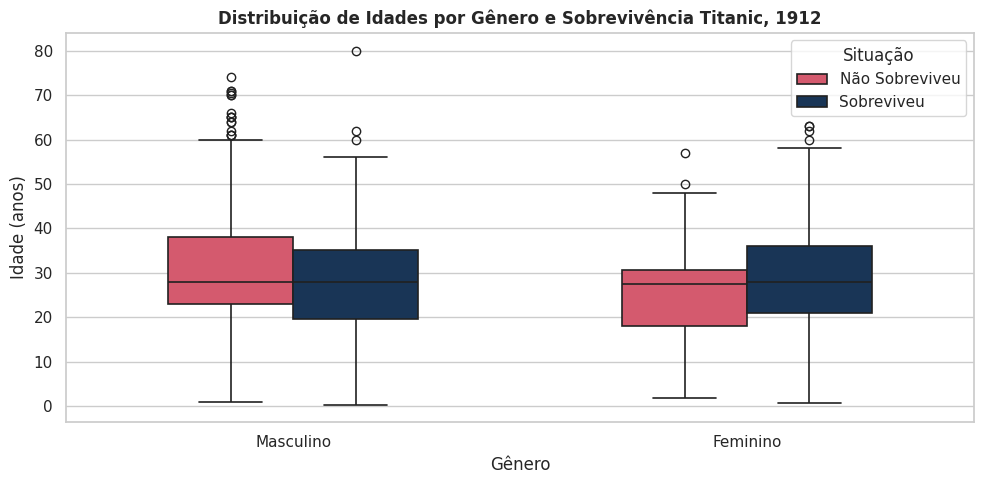

💬 Como interpretar cada elemento do boxplot:
   – Linha do meio = mediana
   – Caixa = entre o 1º e o 3º quartil (50% dos dados estão aqui)
   – Pontos fora dos 'whiskers' = outliers


In [ ]:
# BOXPLOT
# A 'caixa' mostra onde estão os 50% centrais dos dados.
# A linha do meio = mediana. Os pontos isolados = outliers.
# Vantagem sobre o histograma: compara vários grupos ao mesmo tempo.

fig, ax = plt.subplots(figsize=(10, 5))

sns.boxplot(
    data=df_limpo,
    x="sex",
    y="age",
    hue="survived",
    palette={0: "#e94560", 1: "#0f3460"},
    width=0.55,
    linewidth=1.2,
    ax=ax
)

# Personalizando a legenda
handles, _ = ax.get_legend_handles_labels()
ax.legend(handles, ["Não Sobreviveu", "Sobreviveu"], title="Situação", loc="upper right")

ax.set_xlabel("Gênero")
ax.set_ylabel("Idade (anos)")
ax.set_title("Distribuição de Idades por Gênero e Sobrevivência Titanic, 1912", fontweight="bold")
ax.set_xticklabels(["Masculino", "Feminino"])

plt.tight_layout()
plt.show()

print("💬 Como interpretar cada elemento do boxplot:")
print("   – Linha do meio = mediana")
print("   – Caixa = entre o 1º e o 3º quartil (50% dos dados estão aqui)")
print("   – Pontos fora dos 'whiskers' = outliers")


<div style="background:#e8d5f5; border-left:5px solid #5b2c8d; padding:14px 20px; border-radius:6px; margin:12px 0;">
<strong style="color:#5b2c8d;">💡 </strong><span style="color:#5b2c8d;">O boxplot é superior ao histograma quando você quer <strong>comparar vários grupos ao mesmo tempo</strong>. O histograma é melhor para ver a <strong>forma da distribuição</strong> de um único grupo.</span>
</div>

---

### Gráfico 4 — Scatter Plot (Dispersão)

**Pergunta:** *"Existe relação entre a tarifa paga e a classe do bilhete?"*

O scatter plot revela **relações entre duas variáveis numéricas** e ajuda a identificar
clusters, correlações e outliers.


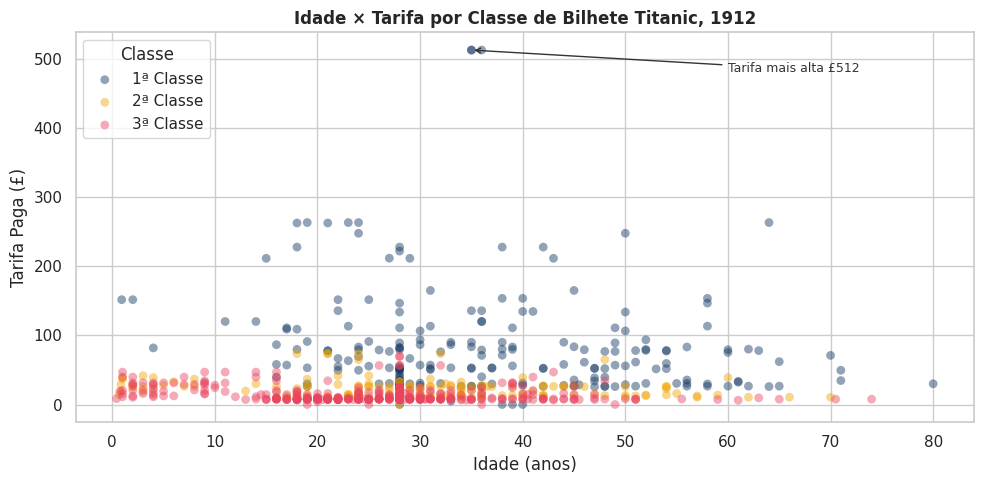

💬 As classes se separam claramente pela tarifa?
   Existe algum passageiro de 3ª classe que pagou muito caro?


In [ ]:
# SCATTER PLOT (DISPERSÃO)
# Cada ponto é um passageiro. Eixo X = idade, Eixo Y = tarifa.
# A cor indica a classe. Padrões espaciais revelam relações entre as variáveis.
# Boa prática: anotar pontos extremos para chamar atenção.

fig, ax = plt.subplots(figsize=(10, 5))

cores_classe = {1: "#0f3460", 2: "#f0a500", 3: "#e94560"}

for classe, grupo in df_limpo.groupby("pclass"):
    ax.scatter(
        grupo["age"],
        grupo["fare"],
        c=cores_classe[classe],
        label=f"{classe}ª Classe",
        alpha=0.45,
        s=40,
        edgecolors="none",
    )

ax.set_xlabel("Idade (anos)")
ax.set_ylabel("Tarifa Paga (£)")
ax.set_title("Idade × Tarifa por Classe de Bilhete Titanic, 1912", fontweight="bold")
ax.legend(title="Classe")

# Boa prática: indicar valores extremos
idx_max = df_limpo["fare"].idxmax()
ax.annotate(
    f"Tarifa mais alta £{df_limpo.loc[idx_max, 'fare']:.0f}",
    xy=(df_limpo.loc[idx_max, "age"], df_limpo.loc[idx_max, "fare"]),
    xytext=(60, 480),
    arrowprops=dict(arrowstyle="->", color="#333"),
    fontsize=9, color="#333"
)

plt.tight_layout()
plt.show()

print("💬 As classes se separam claramente pela tarifa?")
print("   Existe algum passageiro de 3ª classe que pagou muito caro?")


---

### Gráfico 5 — Heatmap de Correlação

**Pergunta:** *"Quais variáveis numéricas se relacionam entre si?"*

O heatmap de correlação mostra a **força e direção** da relação entre pares de variáveis:
- Próximo de **+1**: quando uma sobe, a outra sobe
- Próximo de **-1**: quando uma sobe, a outra desce
- Próximo de **0**: sem relação linear


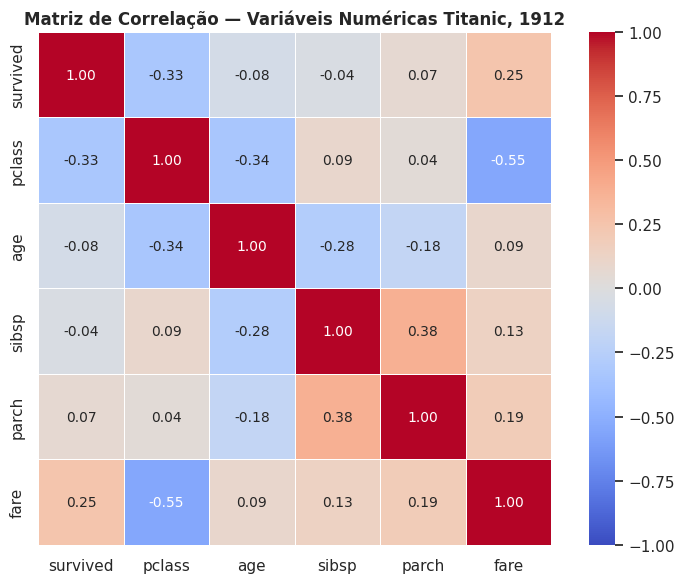

💬 Quais variáveis têm correlação mais forte com 'survived'?
   O que a correlação negativa entre pclass e fare significa?


In [ ]:
# HEATMAP DE CORRELAÇÃO
# Mostra a força da relação entre pares de variáveis numéricas.
# Azul escuro = correlação negativa forte. Vermelho escuro = positiva forte.
# Branco = sem relação linear.
# ATENÇÃO: correlação ≠ causalidade. Sempre interprete com cuidado.

# Selecionando apenas colunas numéricas relevantes
colunas_num = ["survived", "pclass", "age", "sibsp", "parch", "fare"]
corr = df_limpo[colunas_num].corr()

fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(
    corr,
    annot=True,        # mostra os valores dentro de cada célula
    fmt=".2f",         # 2 casas decimais
    cmap="coolwarm",   # azul (negativo) → vermelho (positivo)
    vmin=-1, vmax=1,   # escala fixa de -1 a +1
    square=True,
    linewidths=0.5,
    ax=ax,
    annot_kws={"size": 10},
)

ax.set_title("Matriz de Correlação — Variáveis Numéricas Titanic, 1912", fontweight="bold")
plt.tight_layout()
plt.show()

print("💬 Quais variáveis têm correlação mais forte com 'survived'?")
print("   O que a correlação negativa entre pclass e fare significa?")


<div style="background:#fff3cd; border-left:5px solid #856404; padding:14px 20px; border-radius:6px; margin:12px 0;">
<strong style="color:#856404;">⚠️ </strong><span style="color:#856404;">Correlação mede apenas relação <strong>linear</strong>. Duas variáveis podem ter relação forte mas não-linear e apresentar correlação próxima de zero. Sempre confirme com gráficos!</span>
</div>

---

<div style="background: linear-gradient(90deg, #0f3460 0%, #16213e 100%); padding:20px 25px; border-radius:10px; margin:20px 0;">
    <div>
        <span style="color:#e2b96f; font-size:0.85em; font-weight:bold; letter-spacing:2px;">PARTE 5</span>
        <h2 style="color:white; margin:4px 0 0 0; font-family:'Segoe UI',sans-serif;">Desafio Autônomo</h2>
        <p style="color:#a8d8ea; margin:6px 0 0 0; font-size:0.9em;">"Agora é com você — sem código pronto."</p>
    </div>
</div>

### As regras do desafio

- Cada questão tem uma pergunta analítica real
- **Você escolhe o tipo de gráfico** mais adequado — use a tabela da Parte 4 como referência
- O código deve ter: título, rótulos nos eixos, legenda se necessário
- O gabarito está comentado abaixo de cada desafio — só olhe depois de tentar!


---

### Desafio A

**Pergunta:** *"Mulheres sobreviveram mais do que homens em todas as classes?"*

Dica: você vai precisar cruzar `sex`, `pclass` e `survived` ao mesmo tempo.
Pense em qual tipo de gráfico permite comparar **múltiplos grupos lado a lado**.


In [ ]:
# ✏️ Seu código aqui — Desafio A
# Tipo de gráfico escolhido: ???
# Justificativa: ???




In [ ]:
# ── GABARITO DO DESAFIO A (descomente para ver) ───────────────────────────────
# taxa_sexo_classe = (
#     df_limpo.groupby(["pclass", "sex"])["survived"]
#     .mean()
#     .mul(100)
#     .reset_index()
#     .rename(columns={"survived": "taxa_sobrevivencia"})
# )
#
# fig, ax = plt.subplots(figsize=(10, 5))
#
# classes = sorted(taxa_sexo_classe["pclass"].unique())
# largura = 0.35
# x = np.arange(len(classes))
#
# for i, (sexo, cor, rotulo) in enumerate([("female", "#e94560", "Mulheres"),
#                                            ("male",   "#0f3460", "Homens")]):
#     valores = taxa_sexo_classe[taxa_sexo_classe["sex"] == sexo]["taxa_sobrevivencia"]
#     offset  = (i - 0.5) * largura
#     barras  = ax.bar(x + offset, valores, largura, color=cor,
#                      label=rotulo, edgecolor="white")
#     for b, v in zip(barras, valores):
#         ax.text(b.get_x() + b.get_width()/2, b.get_height() + 1,
#                 f"{v:.0f}%", ha="center", va="bottom", fontsize=10)
#
# ax.set_xticks(x)
# ax.set_xticklabels(["1ª Classe", "2ª Classe", "3ª Classe"])
# ax.set_xlabel("Classe")
# ax.set_ylabel("Taxa de Sobrevivência (%)")
# ax.set_title("Taxa de Sobrevivência por Gênero e Classe\nTitanic, 1912", fontweight="bold")
# ax.legend(title="Gênero")
# ax.set_ylim(0, 110)
# plt.tight_layout(); plt.show()
#
# print("💡 Mulheres sobreviveram mais em TODAS as classes.")
# print("   Na 3ª classe, a diferença ainda é grande (~50% F vs ~15% M).")


---

### Desafio B

**Pergunta:** *"Crianças (age < 12) tiveram taxa de sobrevivência diferente dos adultos?"*

Dica: crie uma nova coluna `faixa_etaria` categórica antes de plotar.


In [ ]:
# ✏️ Seu código aqui — Desafio B
# Passo 1: crie a coluna faixa_etaria
# df_limpo["faixa_etaria"] = ???   # "Criança" se age < 12, "Adulto" caso contrário

# Passo 2: calcule a taxa por faixa
# taxa_faixa = ???

# Passo 3: plote
# Tipo de gráfico escolhido: ???




In [ ]:
# ── GABARITO DO DESAFIO B (descomente para ver) ───────────────────────────────
# df_limpo["faixa_etaria"] = df_limpo["age"].apply(
#     lambda x: "Criança (< 12)" if x < 12 else "Adulto (≥ 12)"
# )
#
# taxa_faixa = df_limpo.groupby("faixa_etaria")["survived"].mean() * 100
# contagem   = df_limpo["faixa_etaria"].value_counts()
#
# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
# fig.suptitle("Sobrevivência por Faixa Etária — Titanic, 1912", fontweight="bold")
#
# # Barras: taxa de sobrevivência
# barras = ax1.bar(taxa_faixa.index, taxa_faixa.values,
#                  color=["#f0a500", "#0f3460"], edgecolor="white", width=0.5)
# for b, v in zip(barras, taxa_faixa.values):
#     ax1.text(b.get_x() + b.get_width()/2, b.get_height() + 1,
#              f"{v:.1f}%", ha="center", fontsize=12, fontweight="bold")
# ax1.set_ylabel("Taxa de Sobrevivência (%)")
# ax1.set_title("Taxa de Sobrevivência")
# ax1.set_ylim(0, 75)
#
# # Barras: contagem de passageiros
# ax2.bar(contagem.index, contagem.values, color=["#0f3460", "#f0a500"],
#         edgecolor="white", width=0.5)
# for i, (idx, v) in enumerate(contagem.items()):
#     ax2.text(i, v + 2, str(v), ha="center", fontsize=12, fontweight="bold")
# ax2.set_ylabel("Número de Passageiros")
# ax2.set_title("Quantidade por Faixa")
#
# plt.tight_layout(); plt.show()
#
# print("💡 Crianças tiveram taxa de sobrevivência maior (~59% vs ~38%).")
# print("   'Mulheres e crianças primeiro' aplicava-se mesmo na 3ª classe.")


---

<div style="background: linear-gradient(90deg, #0f3460 0%, #16213e 100%); padding:20px 25px; border-radius:10px; margin:20px 0;">
    <div style="display:flex; justify-content:space-between; align-items:center; flex-wrap:wrap; gap:10px;">
        <div>
            <span style="color:#e2b96f; font-size:0.85em; font-weight:bold; letter-spacing:2px;">PARTE 6</span>
            <h2 style="color:white; margin:4px 0 0 0; font-family:'Segoe UI',sans-serif;">Reflexão Final</h2>
            <p style="color:#a8d8ea; margin:6px 0 0 0; font-size:0.9em;">"O que aprendemos sobre esses dados?"</p>
        </div>
    </div>
</div>


### Consolidando o aprendizado

<div style="background:#fde8d8; border-left:5px solid #a04000; padding:14px 20px; border-radius:6px; margin:12px 0;">
<strong style="color:#a04000;">🎯 </strong><span style="color:#a04000;">MISSÃO FINAL — Escreva abaixo <strong>3 observações suas</strong> sobre os dados do Titanic. Não copie do notebook — use suas próprias palavras. O que você descobriu que te surpreendeu?</span>
</div>

Esta é a etapa mais importante: escrever consolida o aprendizado muito mais do que ler.


**✏️ Minhas 3 observações sobre o dataset Titanic:**

1. *...*

2. *...*

3. *...*

---

**Algo que me surpreendeu nesta análise:**

*...*

---

**Uma pergunta que ficou sem resposta e eu gostaria de investigar:**

*...*


---

### Painel Resumo — Execute para ver tudo de uma vez

A célula abaixo gera um painel com os 6 gráficos principais lado a lado — uma visão consolidada de tudo que você explorou hoje.


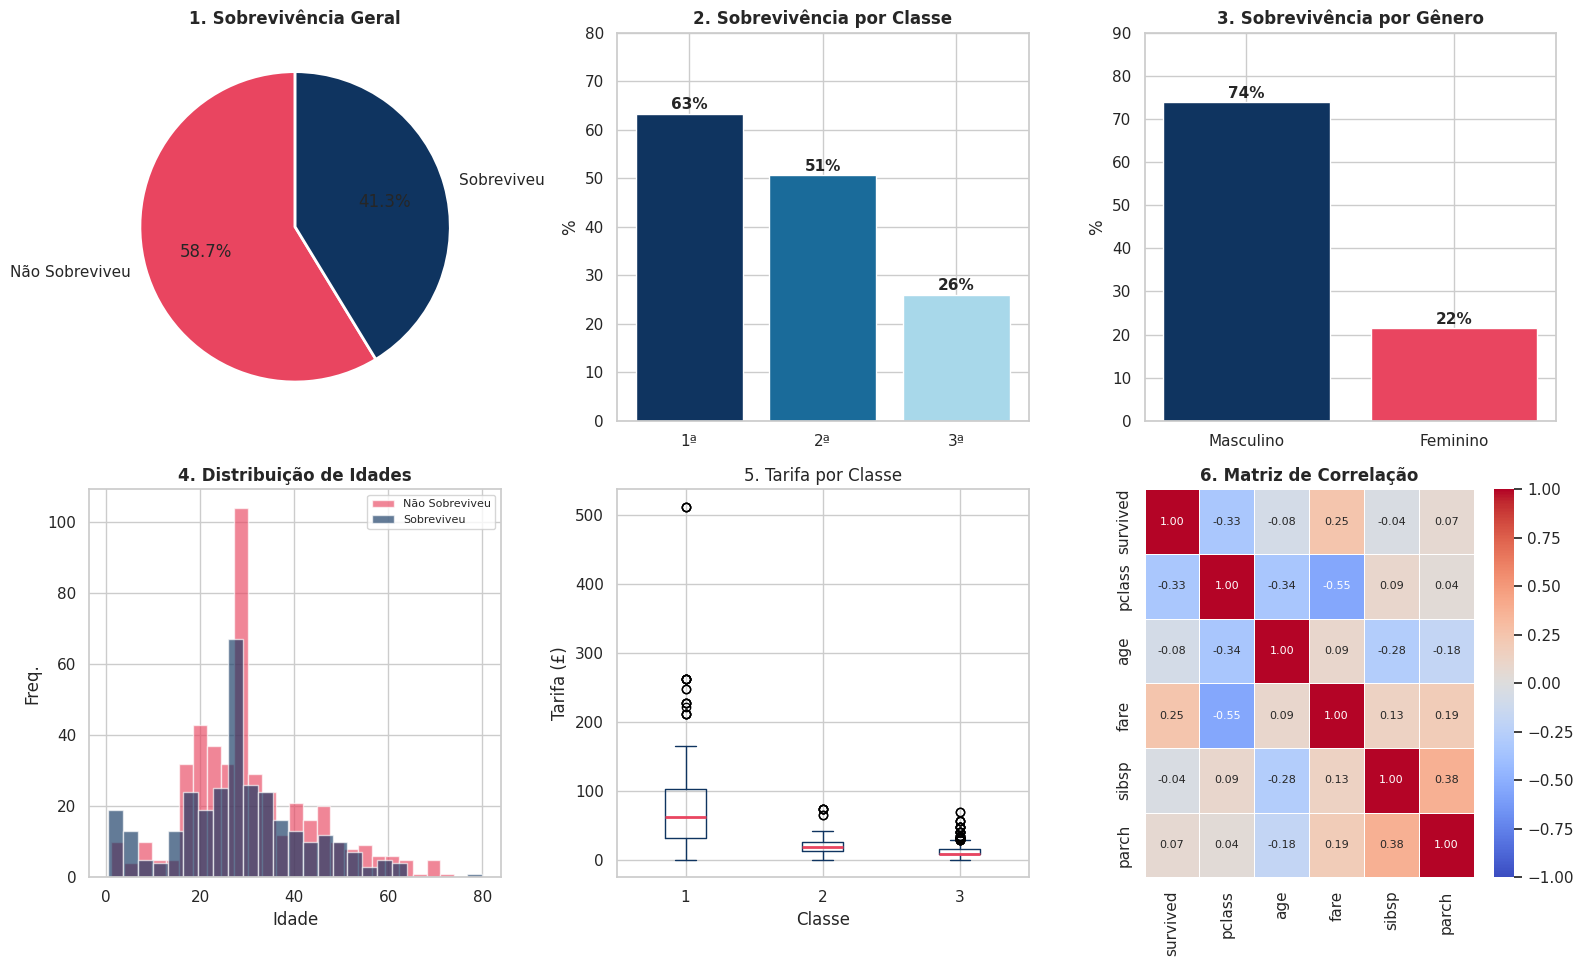

✅ Painel salvo como 'aula03_painel_titanic.png'


In [ ]:
# ── Painel Resumo ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Análise do Titanic — Painel Resumo  |  Ciência de Dados na Prática",
             fontsize=14, fontweight="bold", y=1.01)

C1, C2 = "#0f3460", "#e94560"

# 1. Sobrevivência geral (pizza)
sobrev = df_limpo["survived"].value_counts()
axes[0,0].pie(sobrev.values, labels=["Não Sobreviveu", "Sobreviveu"],
              colors=[C2, C1], autopct="%1.1f%%", startangle=90,
              wedgeprops={"edgecolor":"white","linewidth":2})
axes[0,0].set_title("1. Sobrevivência Geral", fontweight="bold")

# 2. Taxa por classe (barras)
tc = df_limpo.groupby("pclass")["survived"].mean() * 100
axes[0,1].bar(["1ª", "2ª", "3ª"], tc, color=[C1, "#1a6b9a", "#a8d8ea"],
              edgecolor="white")
for i, v in enumerate(tc):
    axes[0,1].text(i, v+1, f"{v:.0f}%", ha="center", fontsize=11, fontweight="bold")
axes[0,1].set_ylabel("%"); axes[0,1].set_ylim(0, 80)
axes[0,1].set_title("2. Sobrevivência por Classe", fontweight="bold")

# 3. Taxa por gênero (barras)
tg = df_limpo.groupby("sex")["survived"].mean() * 100
axes[0,2].bar(["Masculino", "Feminino"], tg, color=[C1, C2], edgecolor="white")
for i, v in enumerate(tg):
    axes[0,2].text(i, v+1, f"{v:.0f}%", ha="center", fontsize=11, fontweight="bold")
axes[0,2].set_ylabel("%"); axes[0,2].set_ylim(0, 90)
axes[0,2].set_title("3. Sobrevivência por Gênero", fontweight="bold")

# 4. Histograma de idades
for s, cor, lbl in [(0,C2,"Não Sobreviveu"),(1,C1,"Sobreviveu")]:
    axes[1,0].hist(df_limpo[df_limpo["survived"]==s]["age"],
                   bins=25, alpha=0.65, color=cor, label=lbl, edgecolor="white")
axes[1,0].set_xlabel("Idade"); axes[1,0].set_ylabel("Freq.")
axes[1,0].set_title("4. Distribuição de Idades", fontweight="bold")
axes[1,0].legend(fontsize=8)

# 5. Boxplot: tarifa por classe
df_limpo.boxplot(column="fare", by="pclass", ax=axes[1,1],
                 boxprops=dict(color=C1), medianprops=dict(color=C2, linewidth=2),
                 whiskerprops=dict(color=C1), capprops=dict(color=C1))
axes[1,1].set_xlabel("Classe"); axes[1,1].set_ylabel("Tarifa (£)")
axes[1,1].set_title("5. Tarifa por Classe", fontweight="bold")
plt.sca(axes[1,1]); plt.title("5. Tarifa por Classe"); plt.suptitle("")

# 6. Heatmap de correlação
colunas_hm = ["survived","pclass","age","fare","sibsp","parch"]
corr = df_limpo[colunas_hm].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            vmin=-1, vmax=1, ax=axes[1,2], linewidths=0.5, annot_kws={"size":8})
axes[1,2].set_title("6. Matriz de Correlação", fontweight="bold")

plt.tight_layout()
plt.savefig("aula03_painel_titanic.png", dpi=130, bbox_inches="tight")
plt.show()
print("✅ Painel salvo como 'aula03_painel_titanic.png'")


---

## Checklist de Boas Práticas — Revisão Final

Antes de entregar qualquer análise, percorra este checklist:

| Item | Verifiquei? |
|------|-------------|
| Explorei o shape e os tipos de dados antes de qualquer gráfico | ☐ |
| Mapeei e tratei todos os valores faltantes | ☐ |
| Verifiquei a presença de duplicatas | ☐ |
| Cada gráfico responde a uma pergunta específica | ☐ |
| Todos os gráficos têm título, rótulos nos eixos e legenda | ☐ |
| Os eixos Y dos gráficos de barra começam em zero | ☐ |
| As cores têm propósito (não são decorativas) | ☐ |
| Registrei minhas observações e conclusões em texto | ☐ |

---


---

<div style="background:#d4edda; border-left:5px solid #155724; padding:14px 20px; border-radius:6px; margin:12px 0;">
<strong style="color:#155724;">Parabéns por concluir a Aula 02!</strong><br>
<span style="color:#155724;">Você fez o percurso completo de um cientista de dados: dados brutos → limpeza → estatísticas → visualizações → conclusões. Exploração de dados não é etapa secundária — é onde as descobertas mais valiosas acontecem.</span>
</div>
